# Week 5: Advanced Machine Learning — Titanic Survival Prediction

## Introduction

This project applies advanced machine learning techniques to the Titanic Survival Prediction dataset. The objective is to build multiple classification models, compare their performance, and identify the model that provides the best predictions.

The project begins with Logistic Regression as the baseline model. Decision Tree, Random Forest, and Gradient Boosting classifiers are then trained and evaluated. Hyperparameter tuning is subsequently applied to improve the performance of one of the models.

The models are evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and a Confusion Matrix.

## Import Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model development, evaluation, and hyperparameter tuning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Train/test split and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
# Load the cleaned Titanic dataset
titanic = pd.read_csv("../data/cleaned/titanic_cleaned.csv")

# Display the first five rows
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Data Exploration

In [3]:
titanic.shape

(891, 11)

In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [5]:
titanic.duplicated().sum()

np.int64(0)

In [6]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Feature and Target Separation

The Survived column is used as the target variable because it represents the outcome we want the model to predict. The remaining relevant columns are used as input features.

In [7]:
# Separate features and target
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

In [8]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [9]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Drop PassengerId, Name and Ticket columns

In [10]:
# Remove columns that will not be used as model features
X = X.drop(["PassengerId", "Name", "Ticket"], axis=1)

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Feature Encoding

The `Sex` and `Embarked` columns contain categorical values. One-hot encoding is used to convert these categorical variables into numerical features that can be used by the machine learning models.

One-hot encoding creates separate binary columns for each category while avoiding an artificial numerical relationship between categories.

In [11]:
# Apply one-hot encoding to categorical variables
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [12]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

## Check for missing values 

In [13]:
# Check for missing values after encoding
X.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

## Feature Scaling

Standardization is applied to the numerical features so that they have a mean close to 0 and a standard deviation close to 1. This is particularly useful for Logistic Regression because the model can be affected by differences in feature scales.

Tree-based models such as Decision Trees, Random Forests, and Gradient Boosting do not require feature scaling, but the same prepared feature set can be used consistently for model comparison.

In [14]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

## Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classification model. It estimates the probability of an observation belonging to a particular class and is suitable for predicting the binary `Survived` target.

The baseline model provides a reference point for comparing the performance of the more advanced classification models.

In [16]:
# Create the baseline Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
baseline_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [17]:
# Make predictions on the test data
baseline_pred = baseline_model.predict(X_test_scaled)

# Get predicted probabilities for ROC-AUC
baseline_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

In [18]:
# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)

print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")
print(f"ROC-AUC: {baseline_roc_auc:.4f}")

Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244
ROC-AUC: 0.8436


In [19]:
# Display the confusion matrix
baseline_cm = confusion_matrix(y_test, baseline_pred)

print(baseline_cm)

[[98 12]
 [23 46]]


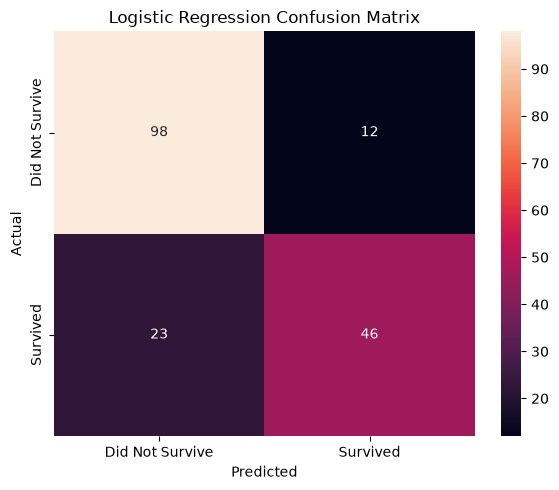

In [20]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

## Decision Tree Classifier

A Decision Tree Classifier predicts the target by recursively splitting the data based on feature values. Unlike Logistic Regression, it can capture non-linear relationships between passenger characteristics and survival.

The initial Decision Tree is trained without hyperparameter tuning so that its performance can be compared fairly with the baseline and other untuned models.

In [21]:
# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model using the unscaled features
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
# Make predictions
dt_pred = decision_tree.predict(X_test)

# Get predicted probabilities
dt_proba = decision_tree.predict_proba(X_test)[:, 1]

In [23]:
# Calculate Decision Tree metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_proba)

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1 Score: {dt_f1:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")

Accuracy: 0.8045
Precision: 0.7500
Recall: 0.7391
F1 Score: 0.7445
ROC-AUC: 0.7792


In [24]:
# Display the Decision Tree confusion matrix
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[93 17]
 [18 51]]


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees. The trees are trained using different samples and feature selections, and their predictions are combined to produce the final classification.

This approach can reduce the variance associated with an individual Decision Tree and improve generalization to unseen data.

In [25]:
# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [26]:
# Make predictions
rf_pred = random_forest.predict(X_test)

# Get predicted probabilities
rf_proba = random_forest.predict_proba(X_test)[:, 1]

In [27]:
# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")

Accuracy: 0.8101
Precision: 0.7778
Recall: 0.7101
F1 Score: 0.7424
ROC-AUC: 0.8287


## Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds models sequentially, with each new model attempting to correct errors made by the previous models.

This allows Gradient Boosting to capture complex relationships in the Titanic dataset and potentially improve classification performance compared with individual Decision Trees.

In [28]:
# Create the Gradient Boosting model
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

# Train the model
gradient_boosting.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [29]:
# Make predictions
gb_pred = gradient_boosting.predict(X_test)

# Get predicted probabilities
gb_proba = gradient_boosting.predict_proba(X_test)[:, 1]

In [30]:
# Calculate Gradient Boosting metrics
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_proba)

print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")
print(f"F1 Score: {gb_f1:.4f}")
print(f"ROC-AUC: {gb_roc_auc:.4f}")

Accuracy: 0.7989
Precision: 0.7895
Recall: 0.6522
F1 Score: 0.7143
ROC-AUC: 0.8165


## Model Comparison

The baseline Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting models are compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

For these classification metrics, higher values indicate better performance.

In [31]:
# Create the model comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        baseline_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        baseline_precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        baseline_recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        baseline_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843610
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.779249
2,Random Forest,0.810056,0.777778,0.710145,0.742424,0.828656
3,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.816535


In [32]:
# Sort models by F1 Score
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.779249
2,Random Forest,0.810056,0.777778,0.710145,0.742424,0.828656
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843610
3,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.816535


### Model Performance Comparison

The performance of the classification models is visualized using F1 Score. F1 Score provides a balance between precision and recall and is useful when evaluating classification performance.

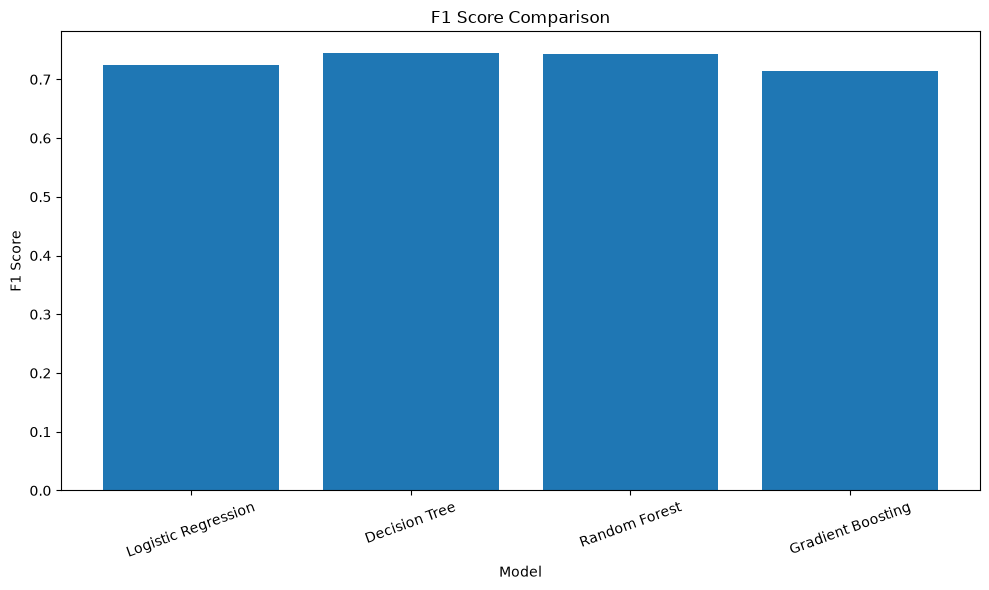

(None,)

In [33]:
# Plot F1 Score comparison
plt.figure(figsize=(10, 6))

plt.bar(results["Model"], results["F1 Score"])

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show(), 

## Model Performance Comparison

The four classification models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Random Forest achieved the highest Accuracy of 0.8101, while Decision Tree achieved the highest F1 Score of 0.7445 and Recall of 0.7391. Logistic Regression achieved the highest ROC-AUC of 0.8436 and the highest Precision of 0.7931.

Gradient Boosting recorded the lowest overall performance across the evaluated models, with an Accuracy of 0.7989 and an F1 Score of 0.7143.

The results show that different models perform better according to different evaluation metrics. Therefore, model selection should consider the objective of the classification problem rather than relying on Accuracy alone.

## Hyperparameter Tuning

Hyperparameter tuning is used to find a combination of parameters that can improve model performance. GridSearchCV evaluates multiple combinations of hyperparameters using cross-validation.

Random Forest is selected for tuning because it achieved the highest Accuracy among the initial models.

In [34]:
# Define the hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

In [35]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42
)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [36]:
# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [37]:
# Display the best hyperparameters
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

In [38]:
# Display the best cross-validation score
grid_search.best_score_

np.float64(0.8217374175120653)

## Tuned Random Forest Evaluation

In [39]:
# Get the best Random Forest model
tuned_rf = grid_search.best_estimator_

In [40]:
# Make predictions using the tuned model
tuned_rf_pred = tuned_rf.predict(X_test)

# Get predicted probabilities
tuned_rf_proba = tuned_rf.predict_proba(X_test)[:, 1]

In [41]:
# Calculate tuned Random Forest metrics
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_precision = precision_score(y_test, tuned_rf_pred)
tuned_rf_recall = recall_score(y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred)
tuned_rf_roc_auc = roc_auc_score(y_test, tuned_rf_proba)

print(f"Accuracy: {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall: {tuned_rf_recall:.4f}")
print(f"F1 Score: {tuned_rf_f1:.4f}")
print(f"ROC-AUC: {tuned_rf_roc_auc:.4f}")

Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244
ROC-AUC: 0.8378


In [42]:
# Display the tuned Random Forest confusion matrix
tuned_rf_cm = confusion_matrix(y_test, tuned_rf_pred)

print(tuned_rf_cm)

[[98 12]
 [23 46]]


In [43]:
# Add the tuned Random Forest results
results.loc[len(results)] = [
    "Tuned Random Forest",
    tuned_rf_accuracy,
    tuned_rf_precision,
    tuned_rf_recall,
    tuned_rf_f1,
    tuned_rf_roc_auc
]

# Display the final comparison
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843610
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.779249
2,Random Forest,0.810056,0.777778,0.710145,0.742424,0.828656
3,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.816535
4,Tuned Random Forest,0.804469,0.793103,0.666667,0.724409,0.837813


In [44]:
# Sort models by F1 Score
final_results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.779249
1,Random Forest,0.810056,0.777778,0.710145,0.742424,0.828656
2,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843610
3,Tuned Random Forest,0.804469,0.793103,0.666667,0.724409,0.837813
4,Gradient Boosting,0.798883,0.789474,0.652174,0.714286,0.816535


## Final Model Comparison

The final comparison evaluates the baseline Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and Tuned Random Forest models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The results are used to determine the strongest model based on the overall classification performance rather than relying on a single metric.

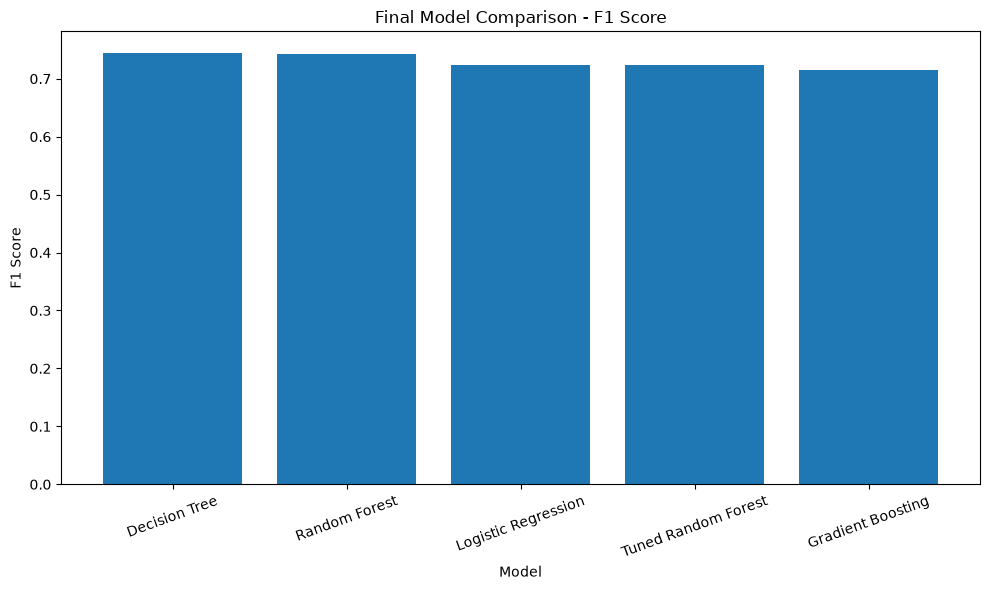

In [45]:
# Plot final F1 Score comparison
plt.figure(figsize=(10, 6))

plt.bar(final_results["Model"], final_results["F1 Score"])

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Final Model Comparison - F1 Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion

This project applied advanced machine learning techniques to the Titanic Survival Prediction dataset. Logistic Regression was first established as the baseline model, followed by Decision Tree, Random Forest, and Gradient Boosting classifiers.

The models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The results showed that different models performed better according to different metrics. Random Forest achieved the highest Accuracy of 0.8101, Decision Tree achieved the highest F1 Score of 0.7445 and Recall of 0.7391, while Logistic Regression achieved the highest ROC-AUC of 0.8436 and Precision of 0.7931.

Hyperparameter tuning was then applied to the Random Forest model using GridSearchCV. The tuned model achieved an Accuracy of 0.8045, Precision of 0.7931, Recall of 0.6667, F1 Score of 0.7244, and ROC-AUC of 0.8378.

The tuned Random Forest did not improve the overall test-set performance compared with the original Random Forest. This demonstrates that hyperparameter tuning does not always lead to better performance on unseen data and that model selection should be based on objective evaluation.

Overall, the initial Random Forest and Decision Tree models provided strong performance across the classification metrics, while Logistic Regression achieved the highest ROC-AUC. The results demonstrate the importance of comparing multiple models and evaluation metrics when selecting a machine learning model.